# Week 4 - Optical Sensing
## Polarization-based sensing

This experiment studies how mechanical perturbations affect the state of polarization (SOP) in an optical fiber and how these changes can be measured using a polarimeter. Light propagates through a single-mode fiber (SMF), where its polarization is not preserved. Mechanical perturbations—such as bending or vibration—change the fiber birefringence, causing the SOP to vary over time. At the polarimeter, the incoming light is split into the three Stokes parameters. A piezoelectric actuator is used to apply controlled perturbations to the fiber, and the resulting Stokes parameters are detected using a polarimeter.

This setup enables controlled analysis of polarization dynamics in optical fibers and serves as a basis for sensing applications where external perturbations are encoded in polarization changes.

<img src="setup_polarization_2.png" width="600"/>

### Additional note: How does a polarimeter work?
A **polarimeter** is an optical instrument that measures the **state of polarization (SOP)** of an electromagnetic wave by determining its polarization-dependent intensity components. The SOP is commonly described using the **Stokes vector**:

$\mathbf{S} = [S_0, S_1, S_2, S_3]^T$


where:
- $S_0$ is the total optical power,
- $S_1$ represents the horizontal/vertical linear polarization component,
- $S_2$ represents the ±45° linear polarization component,
- $S_3$ represents the right/left circular polarization component.

A polarimeter determines these parameters by projecting the incoming light onto a set of known polarization states using optical elements such as **polarizers**, **waveplates**, or **polarization beam splitters**, followed by photodetection.

From the Stokes parameters, several physically meaningful quantities can be derived. One of the most important is the **degree of polarization (DOP)**:

$\mathrm{DOP} = \frac{\sqrt{S_1^2 + S_2^2 + S_3^2}}{S_0}$

which quantifies the fraction of the optical field that is polarized.

For linearly polarized components, the **Angle of Linear Polarization (AOLP)** (also called AOP) is defined as:


$AOLP = \frac{1}{2} \arctan2(S_2, S_1)$


This angle describes the **orientation of the linear polarization ellipse** with respect to a reference axis (typically horizontal). The factor of \(1/2\) arises because polarization states separated by 180° are physically identical, so the AOLP is defined over a range of 0° to 180°. The use of the two-argument arctangent ensures correct quadrant determination.


Geometrically, polarization states are often represented on the **Poincaré sphere**, where:
- fully polarized states lie on the unit sphere surface,
- partially polarized states lie inside the sphere,
- the azimuthal angle corresponds to the AOLP,
- and the elevation corresponds to the ellipticity (related to $S_3$).

Polarimeters can be implemented using different architectures, including division-of-time (sequential measurements with rotating optical elements) and **division-of-amplitude** (parallel detection channels).

The image below illustrates how a division of amplitude works.


<p align="center">
  <img src="polarimeter.png" width="600">
</p>
<p align="center">
  <em>Figure 1: Representation of the working principle of a division of amplitude polarimeter.</em>
</p>

## Activity 

In [2]:
from src.daq import NIDAQ
import nidaqmx
from nidaqmx.constants import AcquisitionType, TerminalConfiguration
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from src.PM1000 import PM1000
from tqdm import tqdm
import os, sys
import pandas as pd

%matplotlib widget

### Connect and configure DAQ

In [9]:
SAMPLING_RATE = 100_000
DEVICE = "Dev2" #Change to match the device on your computer
NUM_CYCLES = 1000

signal_generator = NIDAQ(device = DEVICE, sampling_rate = SAMPLING_RATE, num_cycles = NUM_CYCLES)
polarimeter = PM1000('USB3')

    1: PM1000-100M-CL-FA-L20-D 141
    Select Instrument (0 to Quit):
Connected.


### Acquire Data

In [3]:
#Driver functions for the signal generator and polarimeter
class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

def single_frequency(signal_generator, channel, frequency, voltage):
    """This function will start a continuous signal with the predetermined frequency and amplitude. 
    Only stops when function signal_stop is called.

    Args:
        signal_generator (NIDAQ): NIDAQ reference of your device.
        channel (str): Analog output port.
        frequency (int): Frequency of the signal.
        voltage (float): Peak to peak voltage.
    """
    signal_generator.start_signals([channel], [frequency], [voltage])

def signal_stop(signal_generator):
    """Stops signal.
    """
    signal_generator.stop()


def signal_from_array(signal_generator, channel, array, fs):
    """Plays signal from an array.

    Args:
        signal_generator (NIDAQ): NIDAQ reference of your device.
        channel (str): Analog output port.
        array (numpy.ndarray): Array containing the signal you want to play.
        fs (int): Frequency sampling.
    """

    signal_generator.play_signal_from_array([channel], [array.astype(np.float64)], [fs])

    
def find_ate_me_roundup(target_acq_freq, target_total_time, max_exponent=26):
    """
    Find ATE and ME such that acq_freq >= target_acq_freq (rounded up),
    and total_time is as close as possible to target_total_time.

    Parameters:
    - target_acq_freq: desired acquisition frequency in Hz
    - target_total_time: desired total acquisition time in seconds

    Returns:
    - Dictionary with ATE, ME, actual acquisition frequency and total time
    """
    base_time = 10e-9  # 10 ns

    # Compute the maximum acceptable 2^ATE
    max_pow_ate = 1 / (target_acq_freq * base_time)
    ate = int(np.floor(np.log2(max_pow_ate)))
    ate = min(max(0, ate), max_exponent)

    # Use this ATE to compute actual acquisition frequency
    acq_freq = 1 / (2**ate * base_time)

    # Now choose ME to minimize the time error
    best_error = float('inf')
    best_me = None
    best_total_time = None

    for me in range(0, max_exponent + 1):
        total_time = 2**ate * 2**me * base_time
        error = abs(total_time - target_total_time)

        if error < best_error:
            best_error = error
            best_me = me
            best_total_time = total_time

    return ate, best_me, acq_freq, best_total_time


def read_polarimeter(polarimeter, acq_freq, total_time):

    ATE, ME, acq_freq, total_time = find_ate_me_roundup(target_acq_freq=acq_freq, target_total_time=total_time)
    polarimeter.setATE(ATE)
    polarimeter.setME(ME)
    

    # start recording, manual mode
    polarimeter.start_recording()

    # wait for recording to finish
    polarimeter.waitBusy()
   
    ME = polarimeter.getME()
    data = polarimeter.getsdram(0, 2**ME, 1)

    sop = data[0:, 1:]
    power = data[0:, 0]

    return power, sop, total_time, acq_freq

def acquire_PZT(polarimeter, signal_generator, total_time, frequency, amplitude):
    # Generate the signal
    single_frequency(signal_generator, 'ao0', frequency= frequency, voltage = amplitude)

    # Read the polarimeter
    power, sop, actual_total_time, actual_acq_freq = read_polarimeter(polarimeter, acq_freq = frequency * 8, total_time = total_time)

    #Stop the signal
    signal_stop(signal_generator)

    return sop, actual_total_time, actual_acq_freq, power


In [ ]:
#Setting up the parameters for the acquisition
n_cycles = 2
pzt_frequency = 500
n_pts = 10
acquisition_time = 0.5

pzt_amplitude = np.linspace(0, 9.5, n_pts)
PtP_all = []
S1_all = []#peak to peak values
S2_all = []
S3_all = []

#Nominal values
S1_vals_all = []
S2_vals_all = []
S3_vals_all = []

for meas in tqdm(range(n_cycles), desc="Acquiring data", colour = 'cyan'):
    PtP = []
    S1_ptp = []
    S2_ptp = []
    S3_ptp = []
    S1_vals = []
    S2_vals = []
    S3_vals = []

    for amp in pzt_amplitude:
        with HiddenPrints():
            sop, _, _, power = acquire_PZT(
                polarimeter,
                signal_generator,
                frequency=pzt_frequency,
                total_time=acquisition_time,
                amplitude=amp
            )

        S1 = sop[:, 0]
        S2 = sop[:, 1]
        S3 = sop[:, 2]

        AOP = 0.5 * np.arctan2(S2, S1) * 180 / np.pi
        PtP.append(np.percentile(AOP, 99) - np.percentile(AOP, 1))

        S1_ptp.append(np.percentile(S1, 99) - np.percentile(S1, 1))
        S2_ptp.append(np.percentile(S2, 99) - np.percentile(S2, 1))
        S3_ptp.append(np.percentile(S3, 99) - np.percentile(S3, 1))
        S1_vals.append(np.mean(S1))
        S2_vals.append(np.mean(S2))
        S3_vals.append(np.mean(S3))


    PtP_all.append(PtP)
    S1_all.append(S1_ptp)
    S2_all.append(S2_ptp)
    S3_all.append(S3_ptp)
    S1_vals_all.append(S1_vals)
    S2_vals_all.append(S2_vals)
    S3_vals_all.append(S3_vals)

Acquiring data:   0%|          | 0/2 [00:00<?, ?it/s]

Acquiring data: 100%|██████████| 2/2 [01:26<00:00, 43.11s/it]


### Save data

In [6]:
#Peak to peak and STD for angle of linear polarization (AOP)
PtP_mean = np.mean(PtP_all, axis=0)
PtP_std = np.std(PtP_all, axis=0)

#Peak to peak and STD for each Stokes parameter
S1_mean = np.mean(S1_all, axis=0)
S1_std = np.std(S1_all, axis=0)
S2_mean = np.mean(S2_all, axis=0)
S2_std = np.std(S2_all, axis=0)
S3_mean = np.mean(S3_all, axis=0)
S3_std = np.std(S3_all, axis=0)

#Mean and STD for Stokes parameters
S1_vals_mean = np.mean(S1_vals_all, axis=0)
S1_vals_std = np.std(S1_vals_all, axis=0)
S2_vals_mean = np.mean(S2_vals_all, axis=0)
S2_vals_std = np.std(S2_vals_all, axis=0)
S3_vals_mean = np.mean(S3_vals_all, axis=0)
S3_vals_std = np.std(S3_vals_all, axis=0)

#Save data
data = {
    'Amplitude': pzt_amplitude,
    'PtP_mean': PtP_mean,
    'PtP_std': PtP_std,
    'S1_mean': S1_mean,
    'S1_std': S1_std,
    'S2_mean': S2_mean,
    'S2_std': S2_std,
    'S3_mean': S3_mean,
    'S3_std': S3_std,
    'S1_vals_mean': S1_vals_mean,
    'S1_vals_std': S1_vals_std,
    'S2_vals_mean': S2_vals_mean,
    'S2_vals_std': S2_vals_std,
    'S3_vals_mean': S3_vals_mean,
    'S3_vals_std': S3_vals_std
}

df = pd.DataFrame(data)
df.to_csv('polarization_data.csv', index=False)

### Analyze data

In [3]:
#Read data from file
data = pd.read_csv('polarization_data.csv')

Amplitude = data['Amplitude']
PtP_mean = data['PtP_mean']
PtP_std = data['PtP_std']
S1_mean = data['S1_mean']
S1_std = data['S1_std']
S2_mean = data['S2_mean']
S2_std = data['S2_std']
S3_mean = data['S3_mean']
S3_std = data['S3_std']
S1_vals_mean = data['S1_vals_mean']
S1_vals_std = data['S1_vals_std']
S2_vals_mean = data['S2_vals_mean']
S2_vals_std = data['S2_vals_std']
S3_vals_mean = data['S3_vals_mean']
S3_vals_std = data['S3_vals_std']

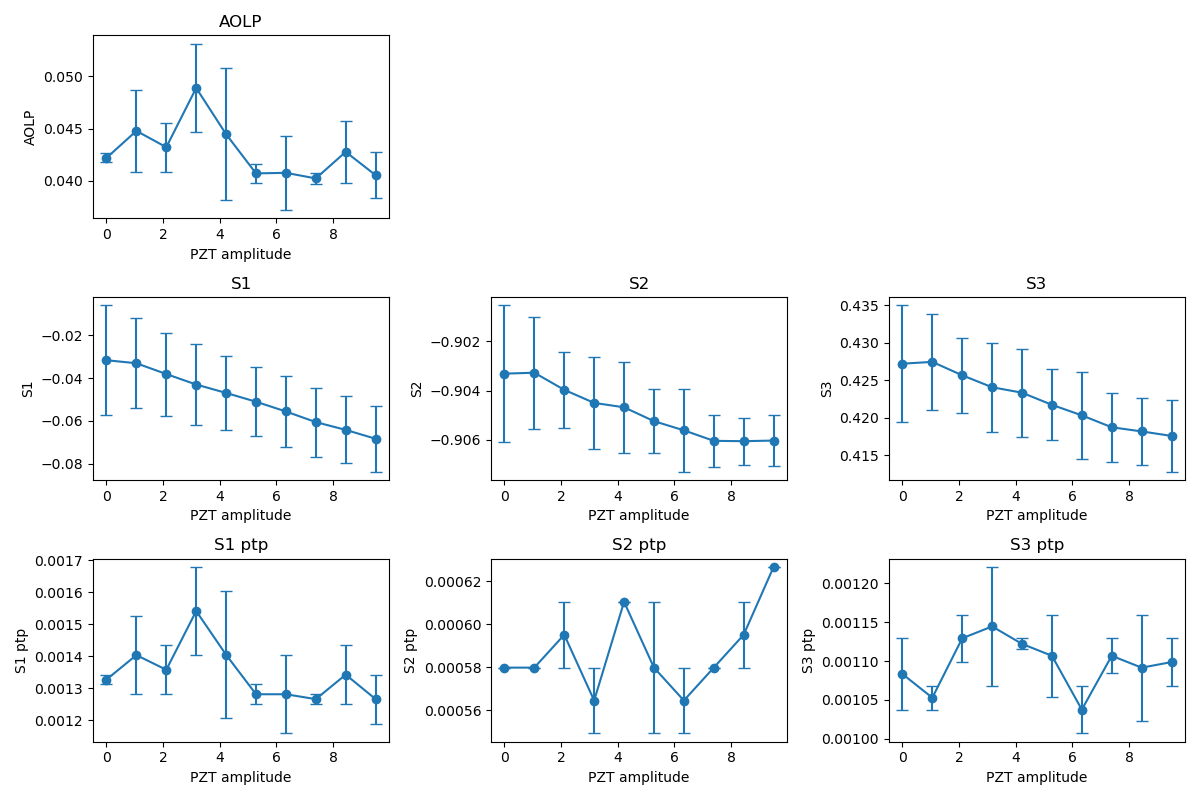

In [4]:
#Plotting the results
fig, axs = plt.subplots(3, 3, figsize=(12, 8))

#Angle of linear polarization (AOLP) peak-to-peak and STD
axs[0, 0].errorbar(Amplitude, PtP_mean, yerr=PtP_std, fmt='o-', capsize=4)
axs[0, 0].set_title('AOLP')
axs[0, 0].set_xlabel('PZT amplitude')
axs[0, 0].set_ylabel('AOLP')

axs[0,1].axis('off')
axs[0,2].axis('off')

#Stokes parameters mean and STD
axs[1, 0].errorbar(Amplitude, S1_vals_mean, yerr=S1_vals_std, fmt='o-', capsize=4)
axs[1, 0].set_title('S1')
axs[1, 0].set_xlabel('PZT amplitude')
axs[1, 0].set_ylabel('S1')

axs[1, 1].errorbar(Amplitude, S2_vals_mean, yerr=S2_vals_std, fmt='o-', capsize=4)
axs[1, 1].set_title('S2')
axs[1, 1].set_xlabel('PZT amplitude')
axs[1, 1].set_ylabel('S2')

axs[1, 2].errorbar(Amplitude, S3_vals_mean, yerr=S3_vals_std, fmt='o-', capsize=4)
axs[1, 2].set_title('S3')
axs[1, 2].set_xlabel('PZT amplitude')
axs[1, 2].set_ylabel('S3')

#Stokes parameters ptp and STD
axs[2, 0].errorbar(Amplitude, S1_mean, yerr=S1_std, fmt='o-', capsize=4)
axs[2, 0].set_title('S1 ptp')
axs[2, 0].set_xlabel('PZT amplitude')
axs[2, 0].set_ylabel('S1 ptp')

axs[2, 1].errorbar(Amplitude, S2_mean, yerr=S2_std, fmt='o-', capsize=4)
axs[2, 1].set_title('S2 ptp')
axs[2, 1].set_xlabel('PZT amplitude')
axs[2, 1].set_ylabel('S2 ptp')

axs[2, 2].errorbar(Amplitude, S3_mean, yerr=S3_std, fmt='o-', capsize=4)
axs[2, 2].set_title('S3 ptp')
axs[2, 2].set_xlabel('PZT amplitude')
axs[2, 2].set_ylabel('S3 ptp')

plt.tight_layout()
plt.show()

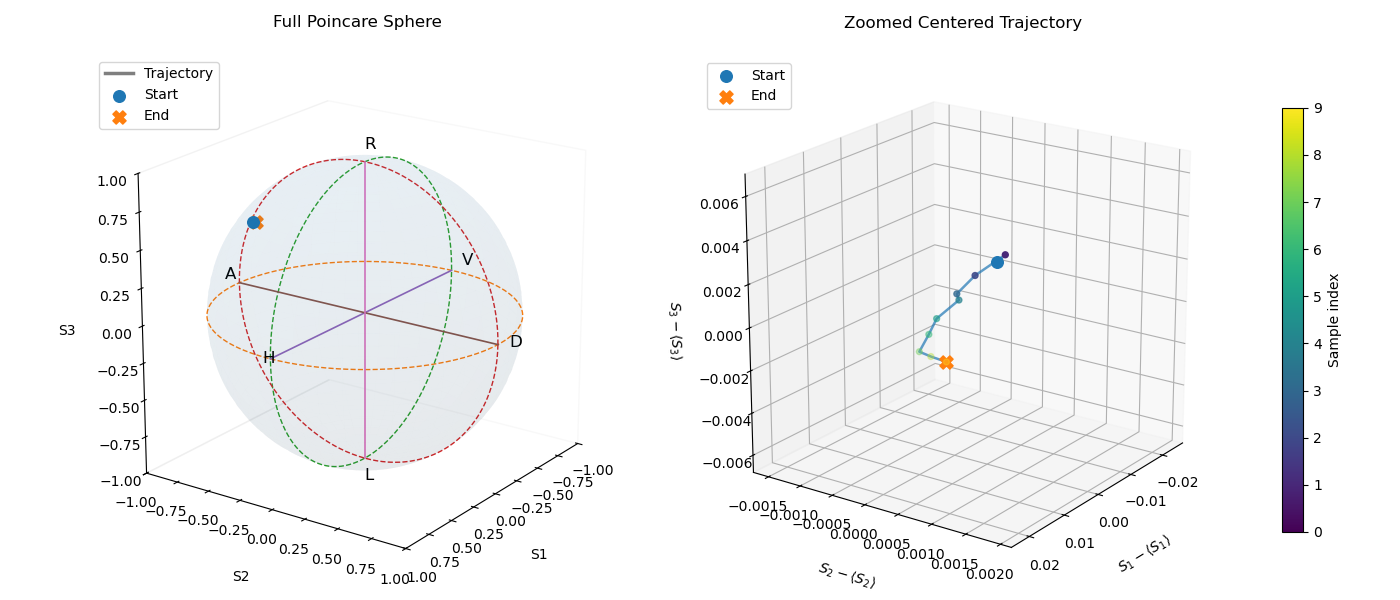

In [6]:
S1 = np.asarray(S1_vals_mean)
S2 = np.asarray(S2_vals_mean)
S3 = np.asarray(S3_vals_mean)

# Centered data for zoomed view
S1c = S1 - np.mean(S1)
S2c = S2 - np.mean(S2)
S3c = S3 - np.mean(S3)

# Helper for dynamic margins
def get_limits(data, frac=0.2, min_margin=1e-4):
    span = np.ptp(data)
    margin = max(span * frac, min_margin)
    return np.min(data) - margin, np.max(data) + margin

# Limits for centered view
xlim_c = get_limits(S1c)
ylim_c = get_limits(S2c)
zlim_c = get_limits(S3c)

# Sphere mesh
u = np.linspace(0, 2*np.pi, 120)
v = np.linspace(0, np.pi, 120)

x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones_like(u), np.cos(v))

# Great circles
t = np.linspace(0, 2*np.pi, 400)

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")

ax1.plot_surface(x, y, z, alpha=0.05, linewidth=0, antialiased=True)

ax1.plot(np.cos(t), np.sin(t), 0*t, '--', linewidth=1)   # equator
ax1.plot(np.cos(t), 0*t, np.sin(t), '--', linewidth=1)   # S1-S3
ax1.plot(0*t, np.cos(t), np.sin(t), '--', linewidth=1)   # S2-S3

ax1.plot([-1, 1], [0, 0], [0, 0], linewidth=1.2)
ax1.plot([0, 0], [-1, 1], [0, 0], linewidth=1.2)
ax1.plot([0, 0], [0, 0], [-1, 1], linewidth=1.2)

ax1.plot(S1, S2, S3, linewidth=2.5, label="Trajectory")
ax1.scatter(S1[0], S2[0], S3[0], s=70, marker='o', label='Start')
ax1.scatter(S1[-1], S2[-1], S3[-1], s=90, marker='X', label='End')

ax1.text( 1.08,  0.00,  0.00, 'H', fontsize=12)
ax1.text(-1.12,  0.00,  0.00, 'V', fontsize=12)
ax1.text( 0.00,  1.08,  0.00, 'D', fontsize=12)
ax1.text( 0.00, -1.12,  0.00, 'A', fontsize=12)
ax1.text( 0.00,  0.00,  1.08, 'R', fontsize=12)
ax1.text( 0.00,  0.00, -1.15, 'L', fontsize=12)

ax1.set_xlabel("S1", labelpad=12)
ax1.set_ylabel("S2", labelpad=12)
ax1.set_zlabel("S3", labelpad=12)

ax1.set_xlim([-1, 1])
ax1.set_ylim([-1, 1])
ax1.set_zlim([-1, 1])
ax1.set_box_aspect([1, 1, 1])

ax1.grid(False)
ax1.xaxis.pane.fill = False
ax1.yaxis.pane.fill = False
ax1.zaxis.pane.fill = False

ax1.view_init(elev=20, azim=35)
ax1.set_title("Full Poincare Sphere", pad=20)
ax1.legend(loc="upper left")


ax2 = fig.add_subplot(1, 2, 2, projection="3d")

idx = np.arange(len(S1c))
sc = ax2.scatter(S1c, S2c, S3c, c=idx, s=18)
ax2.plot(S1c, S2c, S3c, linewidth=1.8, alpha=0.7)

ax2.scatter(S1c[0], S2c[0], S3c[0], s=70, marker='o', label='Start')
ax2.scatter(S1c[-1], S2c[-1], S3c[-1], s=90, marker='X', label='End')

ax2.set_xlabel(r"$S_1 - \langle S_1 \rangle$", labelpad=12)
ax2.set_ylabel(r"$S_2 - \langle S_2 \rangle$", labelpad=12)
ax2.set_zlabel(r"$S_3 - \langle S_3 \rangle$", labelpad=12)

ax2.set_xlim(xlim_c)
ax2.set_ylim(ylim_c)
ax2.set_zlim(zlim_c)
ax2.set_box_aspect([1, 1, 1])

ax2.grid(True)
ax2.view_init(elev=20, azim=35)
ax2.set_title("Zoomed Centered Trajectory", pad=20)

cbar = plt.colorbar(sc, ax=ax2, pad=0.08, shrink=0.8)
cbar.set_label("Sample index")

ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

## Characterize the sensor

### Static features
First, characterize your sensor for a fixed frequency by varying the input peak-to-peak value. This will allow you to determine:
 - span
 - full-scale output
 - dynamic range
 - deadband/saturation (if exists)
 - hysterisis
 - repeatability
 - sensitivity
 - SNR